In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Currently using {DEVICE}")

Currently using cpu


In [2]:
from src.data_import import load_fashion_mnist, load_mnist_digit, load_CIFAR10, load_olivetti

train_loader, test_loader = load_fashion_mnist(16, shuffle=True, class_subset=[9]) #9,7,5])

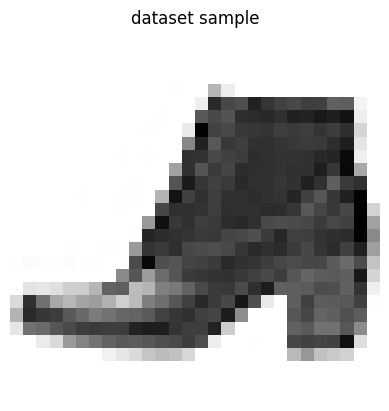

label: 9
shape: torch.Size([16, 1, 28, 28])


In [3]:
from src.plot import show_single_sample, show_grid

x_real, _ = next(iter(train_loader))
show_single_sample(x_real[0], "dataset sample", cmap="Grays")
#print label
print("label:", _[0].item())
print("shape:", x_real.shape)

In [4]:
from src.model import EBM_Old

model = EBM_Old(in_dim=28*28, mid_dim=150, n_heads=3)
model.load_state_dict(torch.load("./Models/FMNIST/ebm_boots_3heads_150mid_32bsz.pth", map_location=DEVICE))
for head in model.heads:
    head.to(DEVICE)

model.to(DEVICE)

EBM_Old(
  (heads): ModuleList(
    (0-2): 3 x EnergyHeadOld(
      (net): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): GELU(approximate='none')
        (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (3): GELU(approximate='none')
        (4): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
        (5): GELU(approximate='none')
        (6): Flatten(start_dim=1, end_dim=-1)
        (7): Linear(in_features=3136, out_features=1, bias=True)
      )
    )
  )
)

In [23]:
from src.model import EnergyHead, EBM, SmallEBM

n_heads = 3
IMAGE_SHAPE = (1, 28, 28)

model = SmallEBM(image_shape=IMAGE_SHAPE, n_heads=n_heads, batch_size=32)
for head in model.heads:
    head.to(DEVICE)

model.to(DEVICE)

SmallEBM(
  (heads): ModuleList(
    (0-2): 3 x SmallEnergyHead(
      (net): Sequential(
        (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1))
        (1): Flatten(start_dim=1, end_dim=-1)
        (2): GELU(approximate='none')
        (3): Linear(in_features=2704, out_features=32, bias=True)
        (4): GELU(approximate='none')
        (5): Linear(in_features=32, out_features=1, bias=True)
      )
    )
  )
)

In [24]:
from src.sampler import ReplaySampler
from src.information import TotalCorrelationEstimator

sampler = ReplaySampler(model, img_shape=IMAGE_SHAPE, buffer_size=600, noise_fraction=0.05, device=DEVICE)
total_correlation_estimator = TotalCorrelationEstimator(n_heads, hidden_dim=16, lr=1e-3)
total_correlation_estimator.to(DEVICE)

In [25]:
from src.train import train_one_epoch_TC, train_one_epoch
#torch.autograd.set_detect_anomaly(True, check_nan=False)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, betas=(0.000, 0.999))

for epoch in range(5):
    epoch_loss = train_one_epoch_TC(
        model, 
        sampler, 
        train_loader, 
        optimizer,

        sample_steps=40,
        sample_step_size=10.0,
        sample_noise_std=0.005,
        energy_reg=1e-1,
        tc_regularizations=1e-2,
        
        tc_estimator=total_correlation_estimator,
        device=DEVICE
    )
    print(f"Epoch {epoch+1}, Loss: {epoch_loss:.4f}")

  0%|          | 0/375 [00:00<?, ?it/s]

100%|██████████| 375/375 [01:07<00:00,  5.59it/s]


  CD:     0.1035
  Reg:    0.0443
  Corr:   0.0011
  E_real: -0.0098
  E_fake: -0.1133
  Gap:    0.1035
Epoch 1, Loss: 0.1490


100%|██████████| 375/375 [01:08<00:00,  5.49it/s]


  CD:     0.0049
  Reg:    0.0005
  Corr:   0.0000
  E_real: -0.0042
  E_fake: -0.0091
  Gap:    0.0049
Epoch 2, Loss: 0.0054


...

  CD:     0.0019
  Reg:    0.0007
  Corr:   0.0000
  E_real: -0.0025
  E_fake: -0.0045
  Gap:    0.0019
Epoch 3, Loss: 0.0026


100%|██████████| 375/375 [01:10<00:00,  5.32it/s]


  CD:     0.0017
  Reg:    0.0007
  Corr:   0.0000
  E_real: -0.0017
  E_fake: -0.0034
  Gap:    0.0017
Epoch 4, Loss: 0.0023


100%|██████████| 375/375 [01:09<00:00,  5.42it/s]

  CD:     0.0014
  Reg:    0.0007
  Corr:   0.0000
  E_real: -0.0008
  E_fake: -0.0022
  Gap:    0.0014
Epoch 5, Loss: 0.0021


EBM DIAGNOSTICS

[1] Energy on real data
  Train  →  mean=0.0106,  std=0.0178
  Test   →  mean=0.0114,  std=0.0245
  |E_test - E_train| = 0.0008  (ok)

[2] Energy on fake data (Langevin samples)
  Fake   →  mean=-0.0087,  std=0.0259
  Gap (E_real_train - E_fake) = 0.0193  (WARNING: gap inverted)

[3] Energy on pure noise
  Noise  →  mean=1.6267,  std=0.0465
  Gap (E_real_train - E_noise) = -1.6161  (ok)

[4] Per-head energy (on train batch)
  Head 0  →  mean=0.2936,  std=0.0110
  Head 1  →  mean=0.0120,  std=0.0089
  Head 2  →  mean=-0.2997,  std=0.0103
  Max off-diagonal correlation: 0.8444  (WARNING: heads are correlated)

[5] Replay buffer
  Buffer size: 600 / 600
  Buffer samples  →  mean=-0.4088,  std=0.7411,  min=-1.0000,  max=1.0000

[6] Visual samples (Langevin from noise)


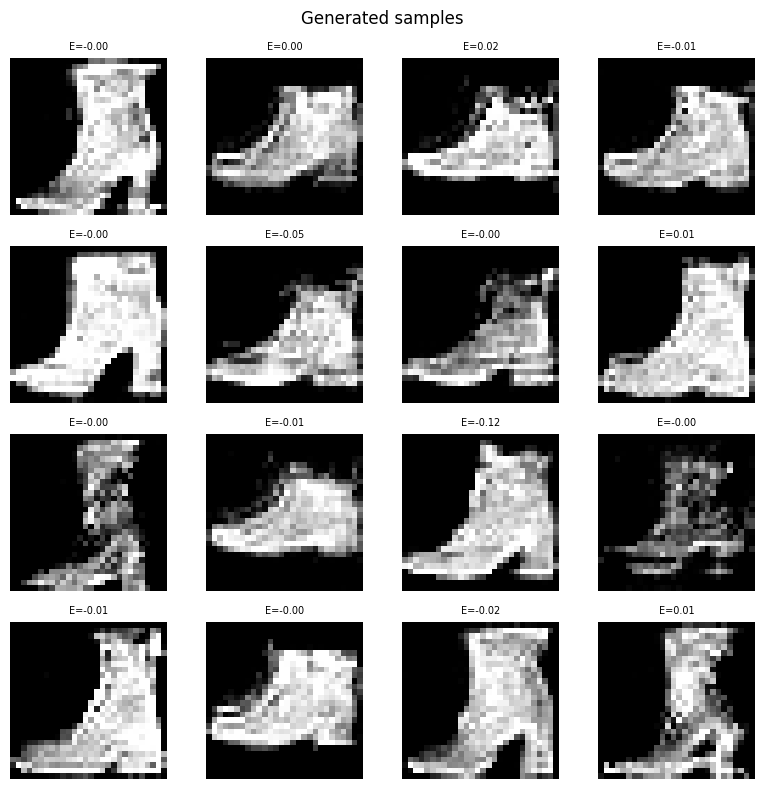


DONE


In [26]:
from src.diagnostic import diagnose

diagnose(model, sampler, IMAGE_SHAPE, train_loader, test_loader, device=DEVICE, n_samples=16)

In [27]:
samples = sampler.generate(10, steps=600, step_size=10.0, noise_std=0.005)

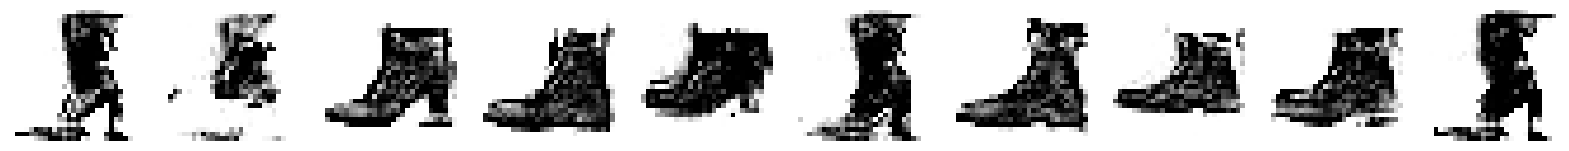

In [28]:
show_grid(samples, 10, cmap="Grays")

In [117]:
%reload_ext autoreload

SmallEBM(
  (heads): ModuleList(
    (0-2): 3 x SmallEnergyHead(
      (net): Sequential(
        (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1))
        (1): Flatten(start_dim=1, end_dim=-1)
        (2): GELU(approximate='none')
        (3): Linear(in_features=2704, out_features=32, bias=True)
        (4): GELU(approximate='none')
        (5): Linear(in_features=32, out_features=1, bias=True)
      )
    )
  )
)

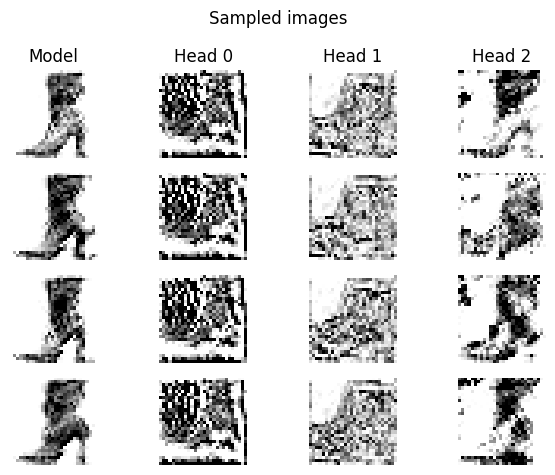

In [ ]:
from src.plot import visualize_heads

model.to("cpu")

fig = visualize_heads(
    model, 
    steps=200, 
    step_size=10.0, 
    noise_std=0.01,
    k=4,
    cmap="Grays",
)

model.to(DEVICE)

In [30]:
def visualize_head_gradients(model, x, device, idx=0):
    """
    Per una singola immagine, mostra dE_i/dx per ogni testa.
    Rivela cosa "guarda" ogni testa nell'immagine.
    """
    model.eval()
    img = x[idx].unsqueeze(0).to(device)  # (1, 1, 28, 28)

    n_heads = len(model.heads)
    fig, axes = plt.subplots(1, n_heads + 1, figsize=(3 * (n_heads + 1), 3))

    # Immagine originale
    axes[0].imshow(img.squeeze().cpu().numpy(), cmap="gray")
    axes[0].set_title("Input")
    axes[0].axis("off")

    for i, head in enumerate(model.heads):
        x_ = img.detach().requires_grad_(True)
        with torch.enable_grad():
            e = head(x_).sum()
            g = torch.autograd.grad(e, x_, only_inputs=True)[0]

        g_np = g.squeeze().cpu().detach().numpy()
        g_np = np.abs(g_np)
        g_np = (g_np - g_np.min()) / (g_np.max() - g_np.min() + 1e-8)

        axes[i + 1].imshow(g_np, cmap="hot")
        axes[i + 1].set_title(f"Head {i}\n|dE/dx|")
        axes[i + 1].axis("off")

    plt.suptitle("Gradient maps per testa", fontsize=12)
    plt.tight_layout()
    plt.show()

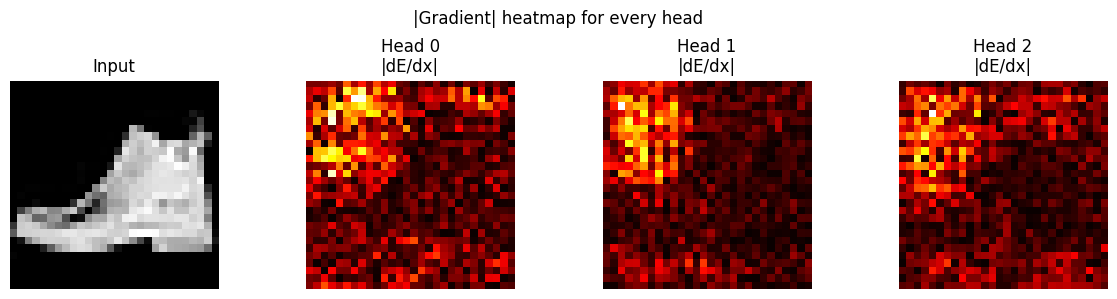

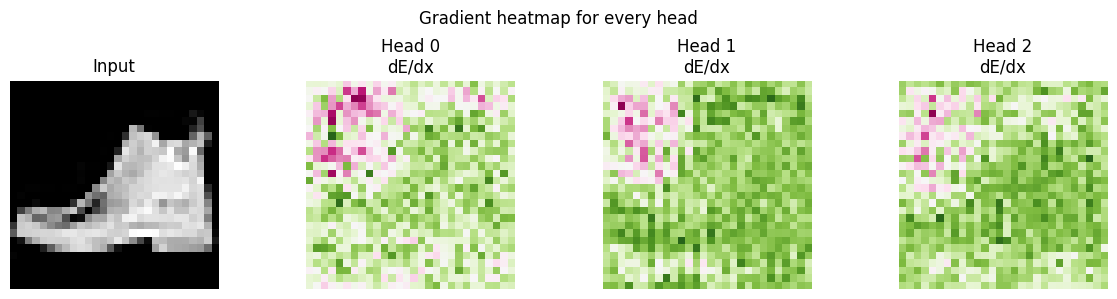

In [8]:
from src.plot import visualize_head_gradients, visualize_head_abs_gradients
it = iter(test_loader)

for _ in range(3):
    it.__next__()
x0 = it.__next__()[0]

visualize_head_abs_gradients(model.to(DEVICE), x0, DEVICE)
visualize_head_gradients(model.to(DEVICE), x0, DEVICE)


In [33]:
from time import time_ns
torch.save(model.state_dict(), f"./models/fmnist/model_fmnist_c579_1epoch_{time_ns()}.pth")

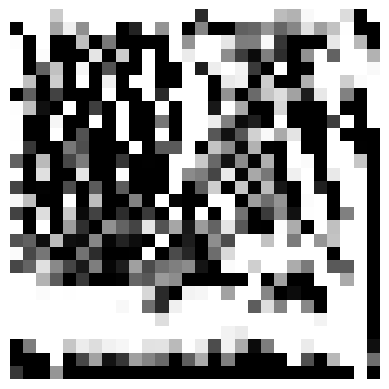

In [79]:
from src.gradient_inspect import synthetize_image_from_head

img, _ = synthetize_image_from_head(model.heads[0].to("cpu"), n_images=1)
show_single_sample(img)
